In [ ]:
# import stuff

import numpy as np 
import matplotlib.pyplot as plt 


In [3]:
# Pritty display



def display_func(x_node_func, func, x_node_interval=(-1, 1), node_count=15, label=None, show_nodes=False):

    x_nodes = x_node_func(node_count)
    x_nodes = rescale(x_nodes, x_node_interval[0], x_node_interval[-1])
    y_nodes = func(x_nodes)

    plt.plot(x_nodes, y_nodes, label=label)

    if show_nodes:
        plt.scatter(x_nodes, y_nodes, label=label)



def finish_display():
    plt.legend()
    plt.grid()
    plt.show()

In [4]:
# Oppg 1 a

# Interpolation
def lagrange_interpolation(x_nodes, y_nodes, x_values):
    if len(x_nodes != y_nodes):
        raise IndexError("Size of x_nodes and y_nodes should be the same")
    
    n = len(x_nodes) - 1

    def q_i(x, x_nodes, i):
        if i < 0 or i > n:
            raise IndexError("Indexen er utanfor node-talet")

        q = 1
        for nr in range(len(x_nodes)):
            if nr == int(i):
                continue
            q *= x - x_nodes[nr]
        return q

    y_values = []
    for x in x_values:

        y_values.append(sum([y_nodes[nr] * q_i(x, x_nodes, nr)/(q_i(x_nodes[nr], x_nodes, nr)) for nr in range(len(x_nodes))]))
    return y_values



# Nodes:
def equidistant_nodes(node_count = 50):
    return np.linspace(-1, 1, node_count)

def chubychub_nodes(node_count = 50):
    count_nr = np.arange(0, node_count)
    return np.cos(((count_nr+1/2)*np.pi)/(node_count))

def rescale(nodes, start, end):
    return (end-start)/2 * nodes + (end+start)/2

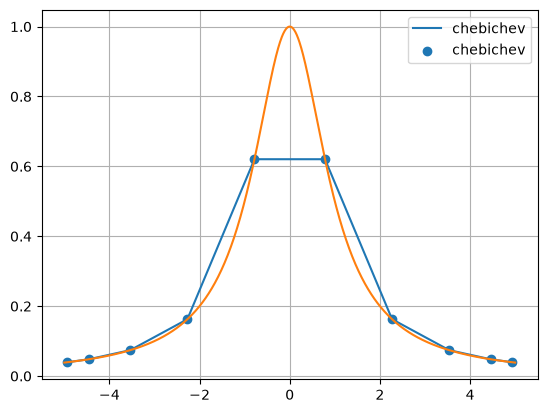

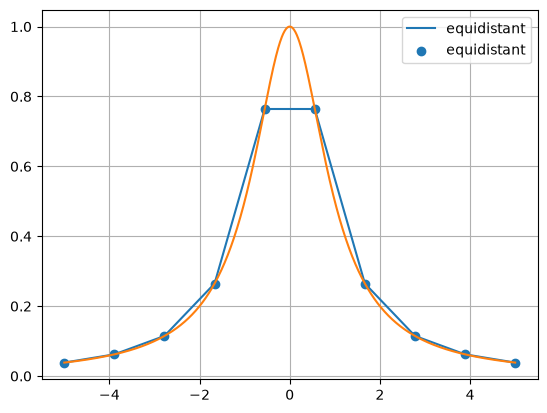

In [ ]:
# plotting mr runge for 10 nodes
def runge_func(x_nodes):
    return 1/(x_nodes**2+1)


display_func(chubychub_nodes, runge_func, (-5, 5), label="chebichev", node_count=10, show_nodes=True)
display_func(equidistant_nodes, runge_func, (-5, 5), node_count=1000)
finish_display()
display_func(equidistant_nodes, runge_func, (-5, 5), label="equidistant", node_count=10, show_nodes=True)
display_func(equidistant_nodes, runge_func, (-5, 5), node_count=1000)
finish_display()

